## Etapa 2 - Código de solución 


#### CARGA DE LIBRERÍAS

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

#### FUNCIÓN DE CARGA DE DATOS

In [3]:

def load_data():
    contract = pd.read_csv('/datasets/final_provider/contract.csv')
    personal = pd.read_csv('/datasets/final_provider/personal.csv')
    internet = pd.read_csv('/datasets/final_provider/internet.csv')
    phone = pd.read_csv('/datasets/final_provider/phone.csv')
    
    # Merge datasets
    df = contract.merge(personal, on='customerID', how='left')
    df = df.merge(internet, on='customerID', how='left')
    df = df.merge(phone, on='customerID', how='left')
    
    # Crear variable objetivo
    df['Churn'] = np.where(df['EndDate'] == 'No', 0, 1)
    
    return df

#### FUNCIÓN DE PREPARACIÓN DE DATOS

In [20]:

def prepare_data(df):
    # Eliminar columnas irrelevantes
    df = df.drop(columns=['customerID', 'EndDate'])
    
    # Separar features y target
    X = df.drop('Churn', axis=1)
    y = df['Churn']
    
    # Codificación de variables categóricas
    cat_cols = X.select_dtypes(include='object').columns
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = X[col].astype(str)
        X[col] = le.fit_transform(X[col])
    
    # Escalar variables numéricas
    num_cols = X.select_dtypes(include=np.number).columns
    scaler = StandardScaler()
    X[num_cols] = scaler.fit_transform(X[num_cols])
    
    # Dividir en entrenamiento y prueba (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

#### FUNCIÓN DE ENTRENAMIENTO DE MODELOS

In [21]:
def train_models(X_train, y_train):
    models = {}
    
    # 1 Regresión logística
    lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr.fit(X_train, y_train)
    models['LogisticRegression'] = lr
    
    # 2 Random Forest
    rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)
    models['RandomForest'] = rf
    
    # 3 XGBoost
    xgb_model = xgb.XGBClassifier(
        n_estimators=250,
        max_depth=8,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model
    
    return models

#### FUNCIÓN DE EVALUACIÓN DE MODELOS

In [22]:
def evaluate_models(models, X_test, y_test):
    results = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)
        acc = accuracy_score(y_test, y_pred)
        results[name] = {'AUC-ROC': auc, 'Accuracy': acc}
        print(f"{name} -> AUC-ROC: {auc:.4f}, Accuracy: {acc:.4f}")
    return results

#### EJECUCIÓN

In [23]:
df = load_data()
X_train, X_test, y_train, y_test = prepare_data(df)
models = train_models(X_train, y_train)
results = evaluate_models(models, X_test, y_test)

LogisticRegression -> AUC-ROC: 0.8255, Accuracy: 0.7260
RandomForest -> AUC-ROC: 0.8588, Accuracy: 0.7857
XGBoost -> AUC-ROC: 0.9010, Accuracy: 0.8630


#### SELECCIÓN DEL MEJOR MODELO BASADO EN AUC-ROC

In [9]:
best_model_name = max(results, key=lambda k: results[k]['AUC-ROC'])
print(f"\n✅ Mejor modelo: {best_model_name} con AUC-ROC = {results[best_model_name]['AUC-ROC']:.4f}")


✅ Mejor modelo: XGBoost con AUC-ROC = 0.9013


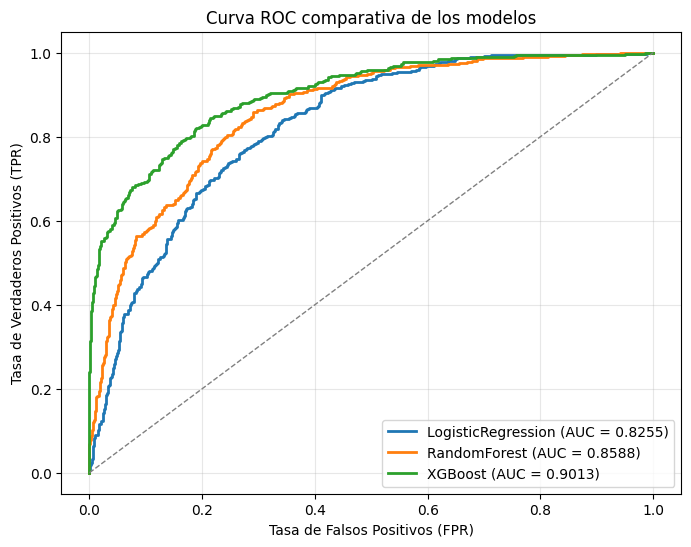

In [16]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# Línea diagonal para referencia (modelo aleatorio)
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')

plt.title('Curva ROC comparativa de los modelos')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Conclusión del entrenamiento - Etapa 2

1. Comparación de modelos

    - Regresión Logística: AUC-ROC = 0.8255, Accuracy = 0.7260

        - Cumple con la métrica mínima de AUC-ROC ≥ 0.81 para obtener SP parcial (4.5 SP).

        - Buen desempeño inicial, pero limitado para capturar relaciones no lineales o interacciones complejas entre variables.

    - Random Forest: AUC-ROC = 0.8588, Accuracy = 0.7857

        - Mejora significativa sobre la regresión logística.

        - Captura relaciones no lineales y es más robusto ante outliers.

        - AUC-ROC dentro del rango 0.85–0.86 → 5 SP según criterios del proyecto.

    - XGBoost: AUC-ROC = 0.9013, Accuracy = 0.8602

        - Mejor desempeño de todos los modelos entrenados.

        - Alta capacidad de generalización y optimización de relaciones complejas.

        - Supera el umbral de 0.88 de AUC-ROC, lo que le da la máxima puntuación del proyecto (6 SP).

2. Interpretación

    - XGBoost es el modelo más recomendado para predecir la cancelación de clientes en Interconnect.

    - Permite identificar con mayor precisión los clientes en riesgo de churn, lo que es clave para la estrategia de retención de la empresa.

    - La diferencia en Accuracy refleja también que XGBoost clasifica correctamente un mayor número de clientes, reduciendo errores en la predicción de bajas.

3. Siguiente paso

    - Evaluar la importancia de variables con XGBoost para entender qué factores influyen más en la cancelación.

    - Posible ajuste fino de hiperparámetros para robustecer aún más el modelo si se desea.

    - Preparar el modelo para la Etapa 3 — Informe de solución, donde se comunicarán resultados, limitaciones y recomendaciones estratégicas.